In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported!")

✅ All libraries imported!


In [2]:
# Load dataset
df = pd.read_csv("data/breast-cancer.csv")
print("Dataset loaded!")
print("Shape:", df.shape)
df.head()

Dataset loaded!
Shape: (569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
# Check data types and nulls
print(df.info())
print("\n")
print("Null values:\n", df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

diagnosis
B    357
M    212
Name: count, dtype: int64


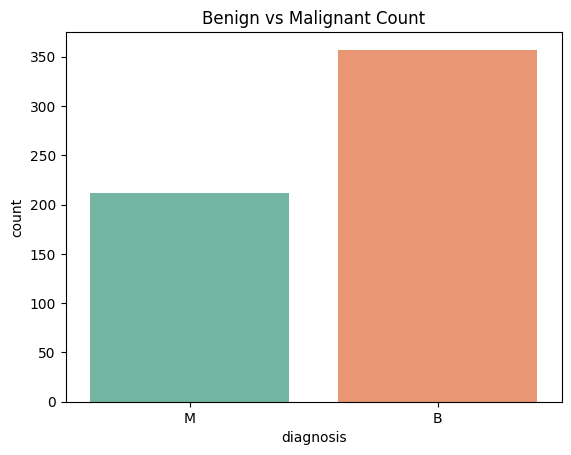

In [4]:
# How many Malignant vs Benign?
print(df['diagnosis'].value_counts())

# Plot it
sns.countplot(x='diagnosis', data=df, palette='Set2')
plt.title('Benign vs Malignant Count')
plt.show()

In [6]:
# Drop unnecessary columns (safely)
cols_to_drop = [col for col in ['id', 'Unnamed: 32'] if col in df.columns]
df = df.drop(cols_to_drop, axis=1)

# Encode target: M = 1, B = 0
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

print("✅ Data cleaned!")
print("Shape now:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

✅ Data cleaned!
Shape now: (569, 31)
Columns: ['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


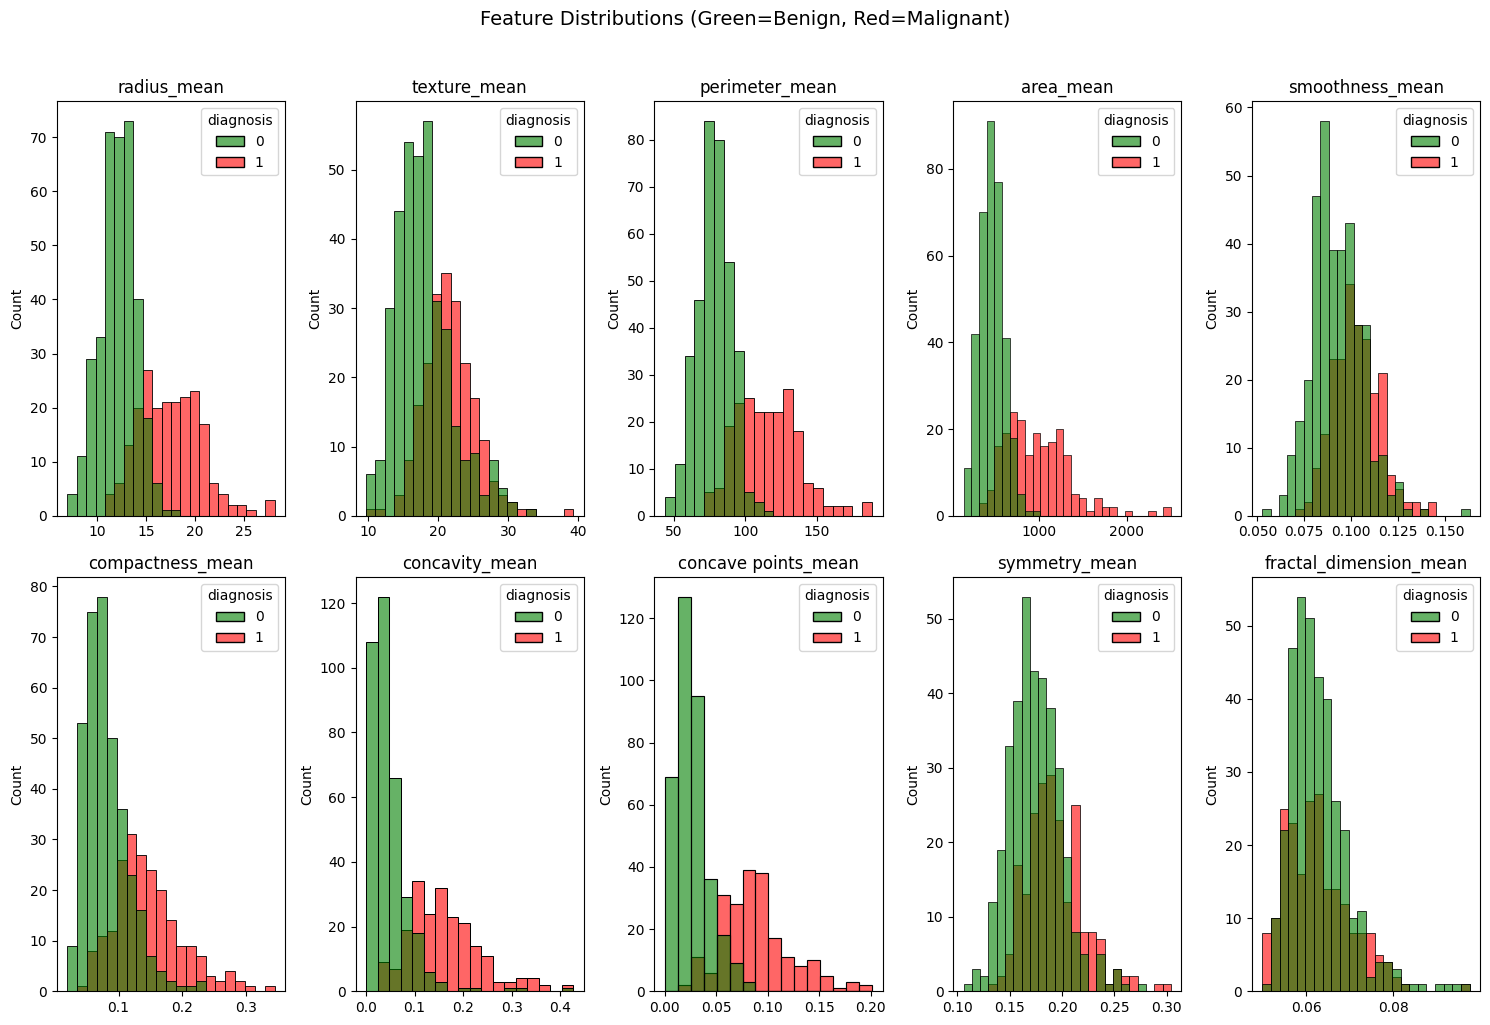

In [7]:
# Plot distribution of first 10 features
features = df.columns[1:11]

plt.figure(figsize=(15, 10))
for i, feature in enumerate(features):
    plt.subplot(2, 5, i+1)
    sns.histplot(data=df, x=feature, hue='diagnosis', 
                 palette={0:'green', 1:'red'}, alpha=0.6)
    plt.title(feature)
    plt.xlabel('')
plt.suptitle('Feature Distributions (Green=Benign, Red=Malignant)', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

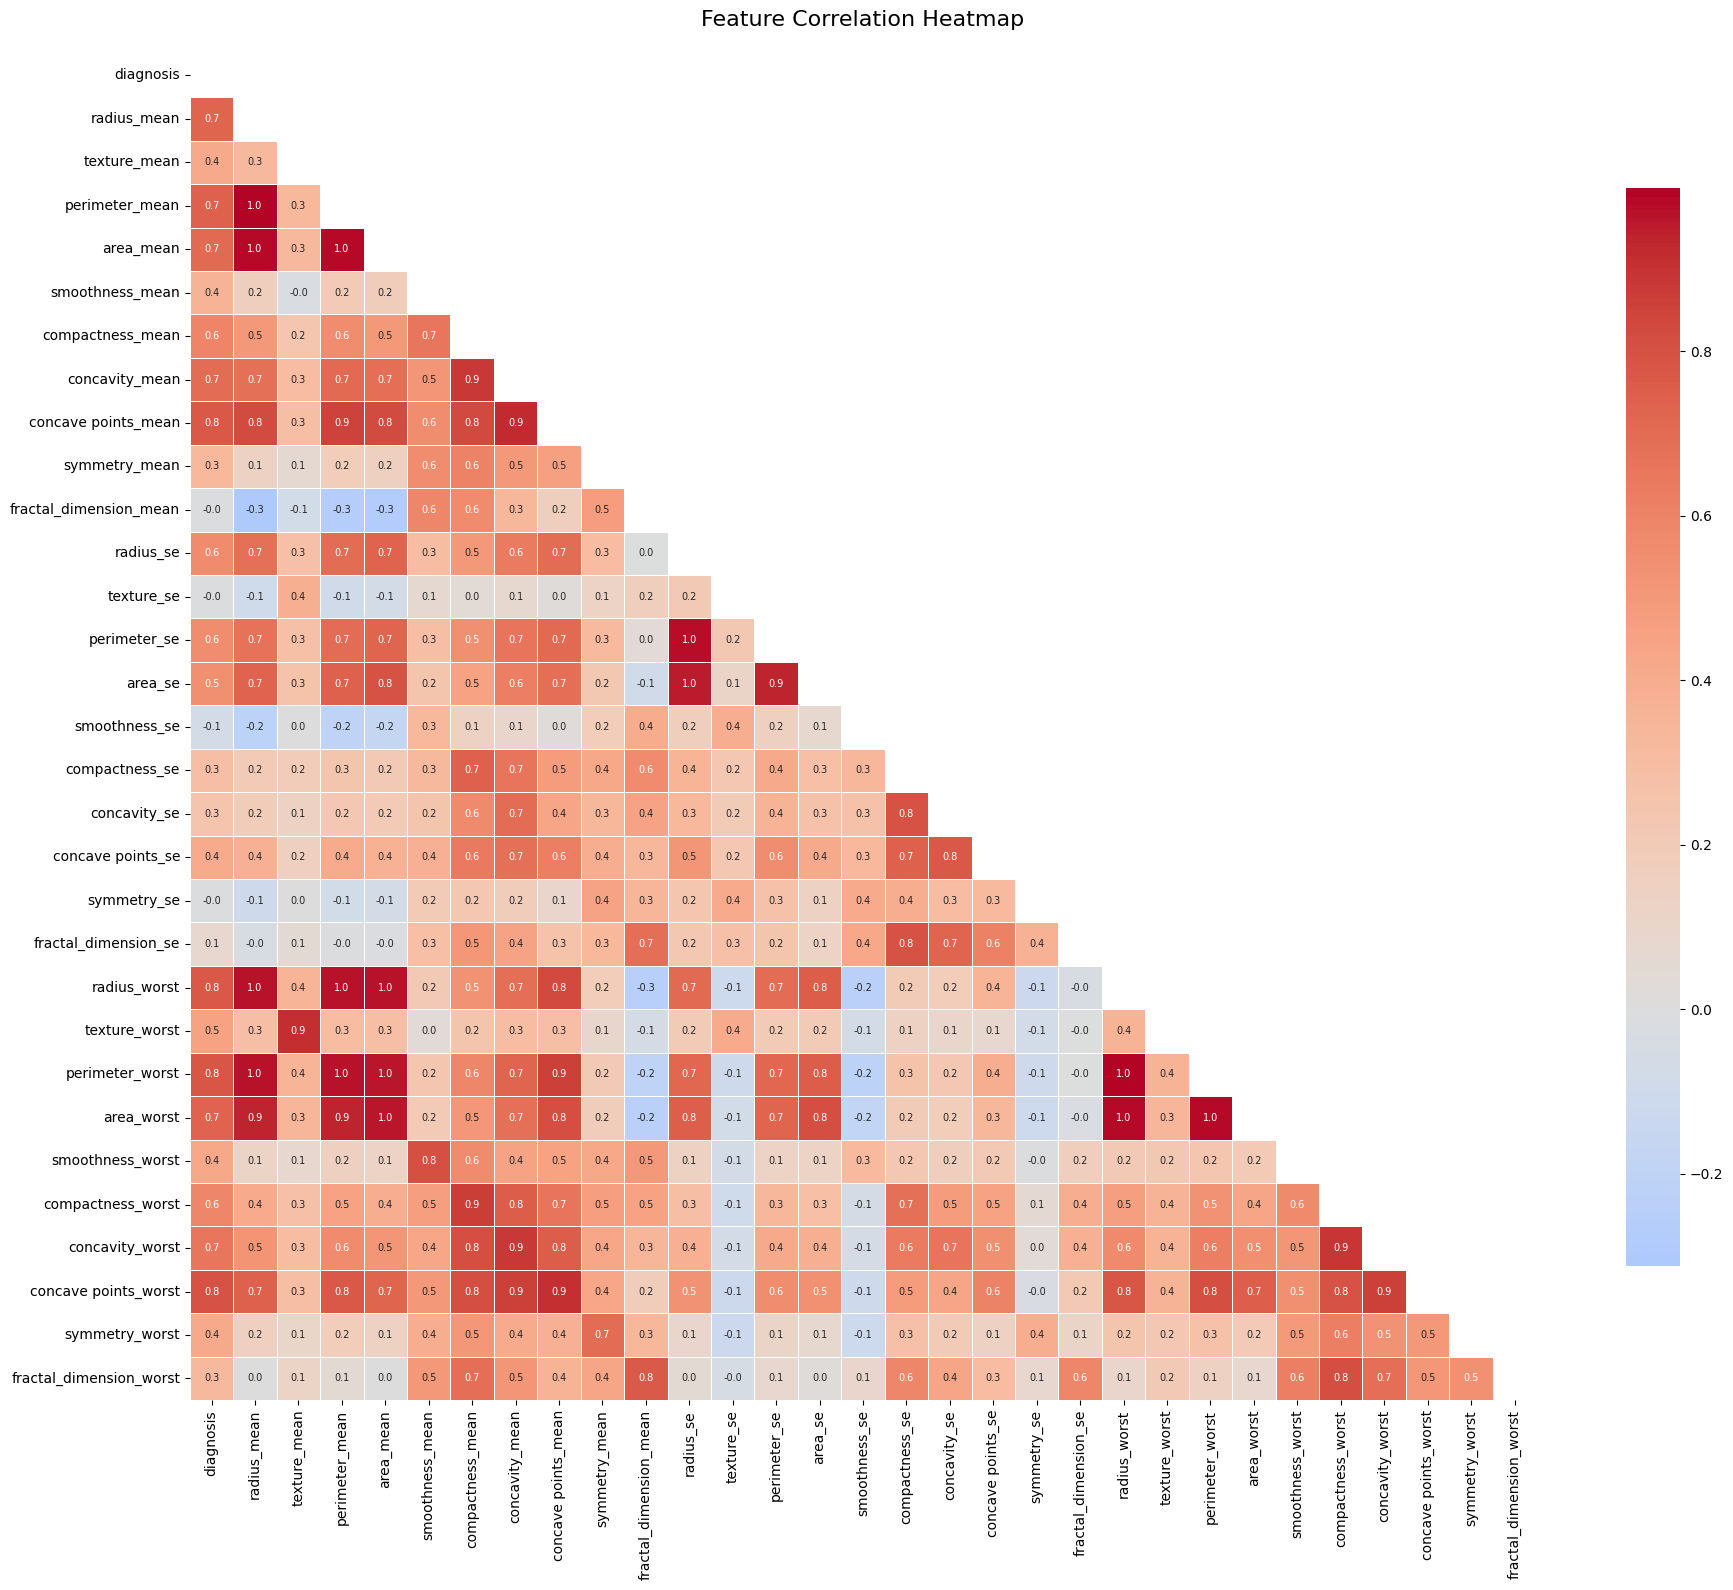

In [8]:
plt.figure(figsize=(20, 16))
correlation = df.corr()
mask = np.triu(np.ones_like(correlation, dtype=bool))

sns.heatmap(correlation, 
            mask=mask,
            annot=True, 
            fmt='.1f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8},
            annot_kws={"size": 7})

plt.title('Feature Correlation Heatmap', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

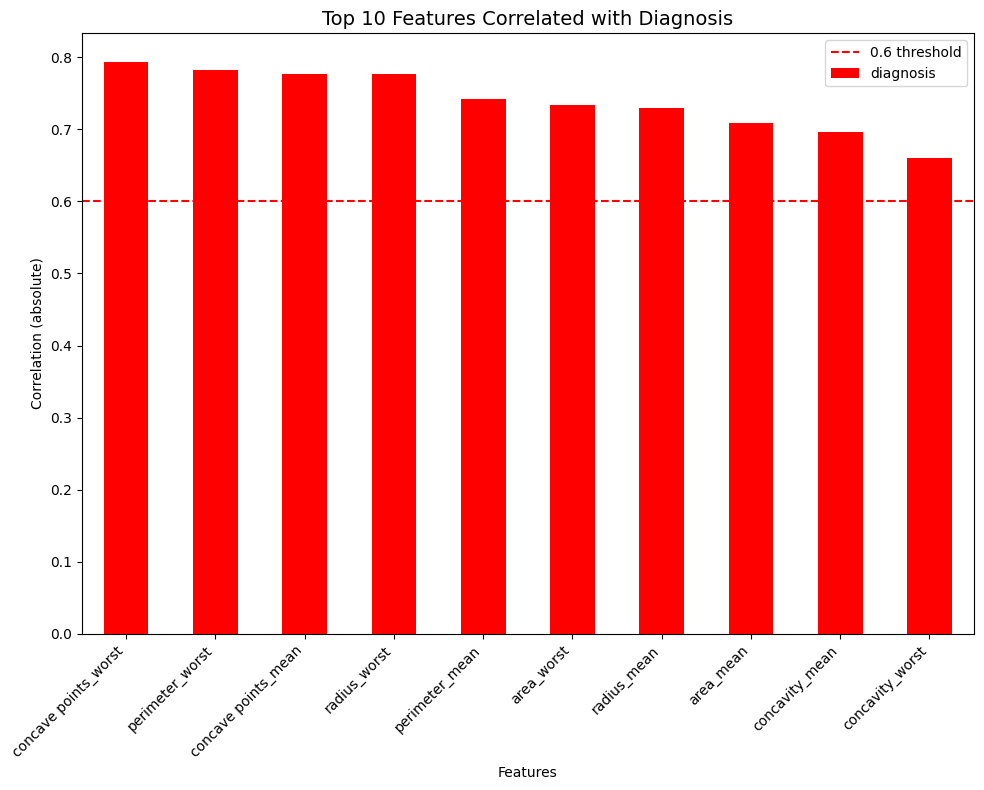


🔍 Top 5 features:
concave points_worst    0.793566
perimeter_worst         0.782914
concave points_mean     0.776614
radius_worst            0.776454
perimeter_mean          0.742636
Name: diagnosis, dtype: float64


In [9]:
# Which features correlate most with cancer?
corr_with_target = df.corr()['diagnosis'].drop('diagnosis')
corr_sorted = corr_with_target.abs().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
corr_sorted.head(10).plot(kind='bar', 
                           color=['red' if x > 0.6 else 'orange' 
                                  for x in corr_sorted.head(10)])
plt.title('Top 10 Features Correlated with Diagnosis', fontsize=14)
plt.xlabel('Features')
plt.ylabel('Correlation (absolute)')
plt.xticks(rotation=45, ha='right')
plt.axhline(y=0.6, color='red', linestyle='--', label='0.6 threshold')
plt.legend()
plt.tight_layout()
plt.show()

print("\n🔍 Top 5 features:")
print(corr_sorted.head())

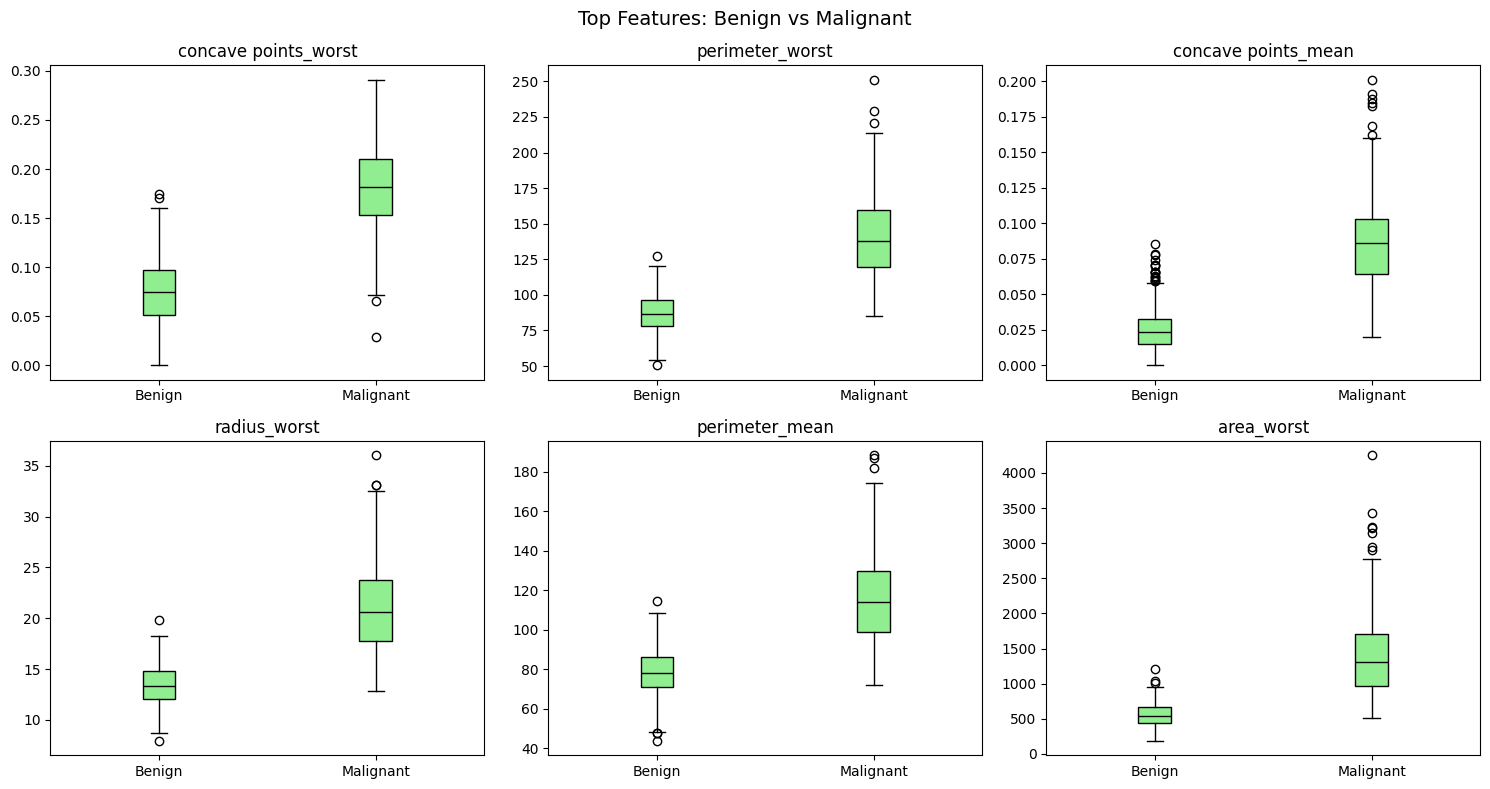

In [11]:
top_features = corr_sorted.head(6).index.tolist()

plt.figure(figsize=(15, 8))
for i, feature in enumerate(top_features):
    plt.subplot(2, 3, i+1)
    
    # Separate benign and malignant
    benign = df[df['diagnosis'] == 0][feature]
    malignant = df[df['diagnosis'] == 1][feature]
    
    plt.boxplot([benign, malignant], 
                patch_artist=True,
                boxprops=dict(facecolor='lightgreen'),
                medianprops=dict(color='black'))
    
    plt.xticks([1, 2], ['Benign', 'Malignant'])
    plt.title(feature)

plt.suptitle('Top Features: Benign vs Malignant', fontsize=14)
plt.tight_layout()
plt.show()

## 🔍 Key EDA Insights

1. **`concave points_worst` and `perimeter_worst`** are the 
   strongest predictors of malignancy (correlation > 0.7)

2. **Malignant tumors** consistently show larger values across 
   radius, perimeter, and area features

3. **Many features are highly correlated with each other** 
   (e.g., radius, perimeter, area) → redundancy exists

4. **Green (Benign) and Red (Malignant)** distributions 
   clearly separate in top features → model should perform well

5. **Some features overlap** between classes → 
   explains where model might make errors

In [12]:
# Separate features (X) and target (y)
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

print("✅ X shape:", X.shape)
print("✅ y shape:", y.shape)
print("Features:", X.columns.tolist())

✅ X shape: (569, 30)
✅ y shape: (569,)
Features: ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 80% train, 20% test
    random_state=42,    # reproducible results
    stratify=y          # keep same M/B ratio in both sets
)

print("✅ Split done!")
print("Training size:", X_train.shape)
print("Testing size: ", X_test.shape)
print("\nTarget distribution in train:")
print(y_train.value_counts())

✅ Split done!
Training size: (455, 30)
Testing size:  (114, 30)

Target distribution in train:
diagnosis
0    285
1    170
Name: count, dtype: int64


In [14]:
# Scale features (important for Logistic Regression)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)  # fit AND transform
X_test_scaled = scaler.transform(X_test)         # ONLY transform

print("✅ Scaling done!")
print("Mean before scaling:", X_train['radius_mean'].mean().round(2))
print("Mean after scaling: ", X_train_scaled[:, 0].mean().round(2))

✅ Scaling done!
Mean before scaling: 14.17
Mean after scaling:  -0.0


## ⚙️ Preprocessing Steps

1. **Split**: 80% train / 20% test (stratified)
2. **Scaling**: StandardScaler applied
   - Required for Logistic Regression
   - Makes all features same scale
   - fit_transform on train only → avoid data leakage